In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
import torch
from matplotlib.colors import LogNorm

import sys
sys.path.insert(0, "..")
from src.data.preprocessing.tica import tica_features, TicaModel

In [9]:
# --- Sequences to process ---
SEQUENCES = ["PPWRECNN", "PLFHVMYV", "NPCLCYML", "IFGWVYTG", "YFPHAGYT", "ISKCKNGE", "DGVAHALS"]

# --- Normalization (from transferable peptide config) ---
POSITION_SCALE = 0.35  # precomputed_std from configs/data/transferable/up_to_8aa.yaml

# --- TICA plot settings ---
TICA_BINS = 50
TICA_CMAP = "BuPu"

# --- Resampling ---
CLIP_QUANTILE = 0.002

# --- Energy ---
ENERGY_DEVICE = "cuda"

In [3]:
def normalize(x, std):
    """Normalize samples: subtract CoM and divide by std."""
    x = x - x.mean(axis=1, keepdims=True)
    x = x / std
    return x


def unnormalize(x, std):
    """Unnormalize samples: multiply by std."""
    return x * std


def load_samples_dict(pt_path: Path) -> dict:
    """Load samples dictionary from .pt file."""
    d = torch.load(pt_path, map_location="cpu", weights_only=False)
    required = {"proposal_samples", "proposal_log_q"}
    if not required.issubset(d):
        raise ValueError(f"{pt_path} missing keys {required - set(d)}")
    return d


def coerce_to_xyz(samples, n_atoms):
    """Convert samples to (N, n_atoms, 3) shape."""
    if isinstance(samples, torch.Tensor):
        samples = samples.cpu().numpy()
    samples = np.asarray(samples)

    if samples.ndim == 3:
        return samples
    if samples.ndim == 2:
        return samples.reshape(-1, n_atoms, 3)

    raise ValueError("Unrecognized sample shape")

In [4]:
def compute_importance_log_weights(log_q, energies_kT, clip_quantile=None):
    """Compute importance weights for resampling.
    
    Matches the logic in transferable_boltzmann_generator_module.py:
    resampling_logits = -proposal_samples_energy - proposal_log_q
    """
    log_w = -energies_kT - log_q

    if clip_quantile is None:
        return log_w, np.ones(len(log_w), bool)

    # Clip high logits (same as clip_reweighting_logits in eval)
    cutoff = np.quantile(log_w, 1.0 - clip_quantile)
    mask = log_w <= cutoff
    return log_w[mask], mask


def resample_with_importance_weights(samples, log_w, n_samples=None, seed=0):
    """Resample using importance weights (multinomial resampling)."""
    g = torch.Generator().manual_seed(seed)
    probs = torch.softmax(torch.tensor(log_w, dtype=torch.float64), dim=0)

    if n_samples is None:
        n_samples = len(samples)

    idx = torch.multinomial(probs, n_samples, replacement=True, generator=g)
    return samples[idx.numpy()]

In [5]:
def make_openmm_energy_fn(pdb_path: Path, device="cuda"):
    """Create an OpenMM energy function for the given molecule.
    
    Note: This expects UNNORMALIZED coordinates in nm.
    """
    import openmm
    import openmm.app
    import openmm.unit

    pdb = openmm.app.PDBFile(str(pdb_path))
    forcefield = openmm.app.ForceField(
        "amber99sbildn.xml", "tip3p.xml", "amber99_obc.xml"
    )

    system = forcefield.createSystem(
        pdb.topology,
        nonbondedMethod=openmm.app.NoCutoff,
        constraints=None,
    )

    integrator = openmm.LangevinMiddleIntegrator(
        310 * openmm.unit.kelvin,
        1.0 / openmm.unit.picosecond,
        1.0 * openmm.unit.femtosecond,
    )

    platform = openmm.Platform.getPlatformByName("CUDA" if device == "cuda" else "CPU")
    context = openmm.Context(system, integrator, platform)

    kT = (openmm.unit.MOLAR_GAS_CONSTANT_R * 310 * openmm.unit.kelvin).value_in_unit(
        openmm.unit.kilojoule_per_mole
    )

    def energy_fn(x_nm):
        """Compute energy in units of kT. Input should be in nm."""
        E = np.empty(len(x_nm))
        for i, x in enumerate(x_nm):
            context.setPositions(x * openmm.unit.nanometer)
            state = context.getState(getEnergy=True)
            E[i] = state.getPotentialEnergy().value_in_unit(
                openmm.unit.kilojoule_per_mole
            ) / kT
        return E

    return energy_fn

In [6]:
def compute_tica_coordinates(samples_xyz, topology, tica_model):
    """Compute TICA coordinates for samples.
    
    This matches the exact flow in plot_tica.py:
    1. Create MDTraj trajectory from samples (expects nm coordinates)
    2. Compute TICA features (distances + dihedrals)
    3. Transform features using TICA model
    
    Note: samples_xyz should be UNNORMALIZED (in nm).
    """
    traj = md.Trajectory(samples_xyz.astype(np.float32), topology)
    features = tica_features(traj)
    tics = tica_model.transform(features)
    if isinstance(tics, torch.Tensor):
        tics = tics.cpu().numpy()
    return tics


def plot_tic01(ax, tics, tics_lims=None, cmap="viridis", bins=100):
    """Create a 2D histogram of TIC0 vs TIC1.
    
    Matches the style from src/evaluation/plots/plot_tica.py
    """
    h = ax.hist2d(
        tics[:, 0], tics[:, 1],
        bins=bins,
        norm=LogNorm(),
        cmap=cmap,
    )
    ax.set_xlabel("TIC0", fontsize=12)
    ax.set_ylabel("TIC1", fontsize=12)
    if tics_lims is not None:
        ax.set_xlim(tics_lims[:, 0].min(), tics_lims[:, 0].max())
        ax.set_ylim(tics_lims[:, 1].min(), tics_lims[:, 1].max())
    # ax.set_xticks([])
    # ax.set_yticks([])
    ax.tick_params(direction='in', which='both', top=True, right=True, left=True, bottom=True)
    return h

In [7]:
def process_sequence(seq, position_scale=POSITION_SCALE, clip_quantile=CLIP_QUANTILE, device=ENERGY_DEVICE, seed=0):
    """Process a single sequence: load MD data, compute TICA, resample proposals, compute resampled TICA."""
    pdb_path = Path(f"data/{seq}.pdb")
    npz_path = Path(f"data/{seq}_subsampled.npz")
    pt_path = Path(f"data/{seq}_samples.pt")

    # Load MD ground truth and TICA model
    sub = np.load(npz_path)
    md_pos = sub["positions"]
    tica_model = TicaModel(projection=sub["tica_projection"], mean=sub["tica_mean"], dim=sub["tica_dim"])
    topology = md.load_topology(pdb_path)
    n_atoms = topology.n_atoms

    print(f"  MD: {md_pos.shape}, topology: {n_atoms} atoms")

    # MD TICA
    tics_md = compute_tica_coordinates(md_pos, topology, tica_model)

    # Load and resample proposal samples
    sd = load_samples_dict(pt_path)
    prop_norm = coerce_to_xyz(sd["proposal_samples"], n_atoms)
    log_q = sd["proposal_log_q"].cpu().numpy()
    prop_unnorm = unnormalize(prop_norm, position_scale)

    print(f"  Loaded {len(prop_norm)} proposal samples")

    # Compute energies
    efn = make_openmm_energy_fn(pdb_path, device)
    print(f"  Computing energies...")
    energies = efn(prop_unnorm.astype(np.float32))

    # Importance resampling
    log_w, mask = compute_importance_log_weights(log_q, energies, clip_quantile)
    resampled = resample_with_importance_weights(prop_unnorm[mask], log_w, n_samples=None, seed=seed)
    print(f"  Resampled {len(resampled)} samples (clipped {(~mask).sum()})")

    # Resampled TICA
    tics_res = compute_tica_coordinates(resampled, topology, tica_model)

    # Axis limits (integer bounds from combined data)
    all_tics = np.concatenate([tics_md, tics_res], axis=0)
    xlim = (int(np.floor(all_tics[:, 0].min())), int(np.ceil(all_tics[:, 0].max())))
    ylim = (int(np.floor(all_tics[:, 1].min())), int(np.ceil(all_tics[:, 1].max())))

    return {"tics_md": tics_md, "tics_resampled": tics_res, "xlim": xlim, "ylim": ylim}


# Process all sequences
all_results = {}
for i, seq in enumerate(SEQUENCES):
    print(f"\n[{i+1}/{len(SEQUENCES)}] Processing {seq}...")
    all_results[seq] = process_sequence(seq, seed=i * 10)

print("\nAll sequences processed!")


[1/7] Processing PPWRECNN...
  MD: (10000, 133, 3), topology: 133 atoms
  Loaded 200000 proposal samples
  Computing energies...


  Resampled 199600 samples (clipped 400)



[2/7] Processing PLFHVMYV...
  MD: (10000, 143, 3), topology: 143 atoms
  Loaded 200000 proposal samples
  Computing energies...


  Resampled 199600 samples (clipped 400)



[3/7] Processing NPCLCYML...
  MD: (10000, 129, 3), topology: 129 atoms
  Loaded 200000 proposal samples
  Computing energies...


...

  Resampled 199600 samples (clipped 400)



[6/7] Processing ISKCKNGE...
  MD: (10000, 124, 3), topology: 124 atoms
  Loaded 200000 proposal samples
  Computing energies...


  Resampled 199600 samples (clipped 400)



[7/7] Processing DGVAHALS...
  MD: (10000, 105, 3), topology: 105 atoms
  Loaded 200000 proposal samples
  Computing energies...


  Resampled 199600 samples (clipped 400)

All sequences processed!


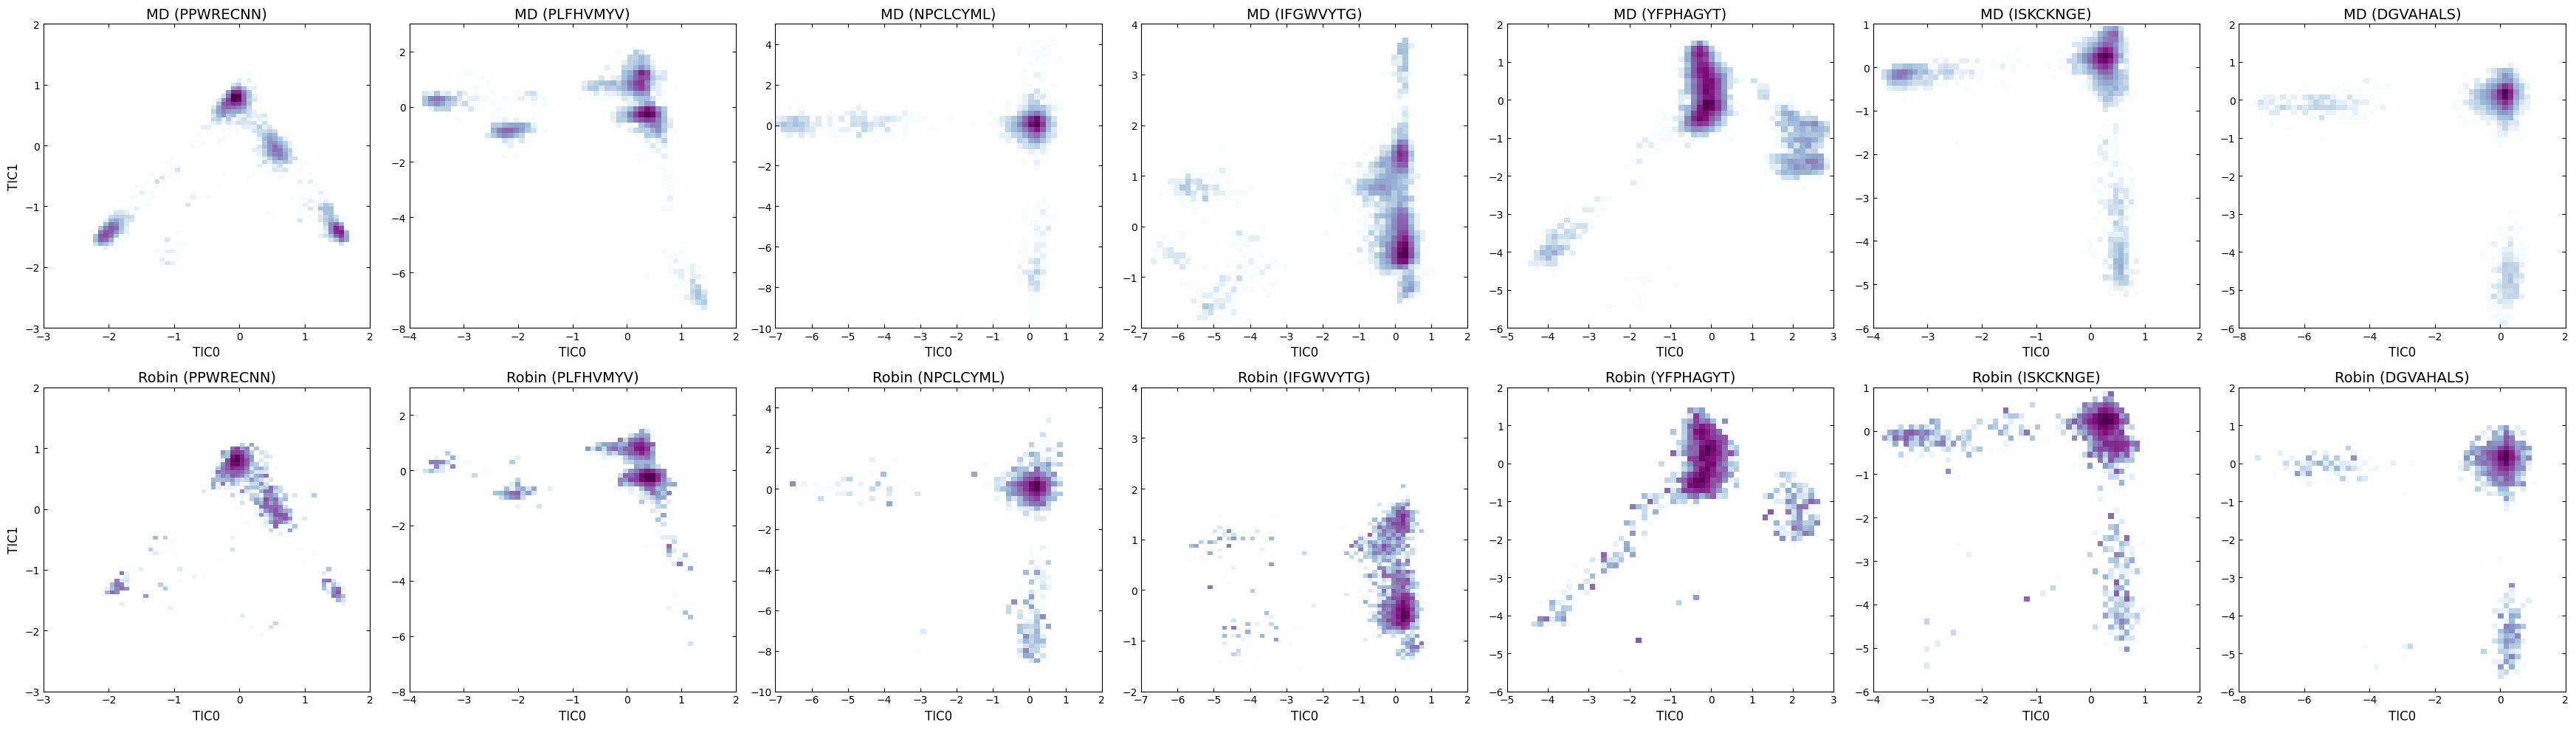


Figure saved to figures/combined_tica_2row.pdf


In [11]:
# ========================================================
# Combined 2-row plot: Row 1 = MD, Row 2 = Robin
# ========================================================
n_seq = len(SEQUENCES)
fig, axes = plt.subplots(2, n_seq, figsize=(5 * n_seq, 10))

for col, seq in enumerate(SEQUENCES):
    res = all_results[seq]
    xlim = res["xlim"]
    ylim = res["ylim"]

    # Row 0: MD
    ax_md = axes[0, col]
    plot_tic01(ax_md, res["tics_md"], cmap=TICA_CMAP, bins=TICA_BINS)
    ax_md.set_title(f"MD ({seq})", fontsize=14)
    ax_md.set_xlim(*xlim)
    ax_md.set_ylim(*ylim)
    if col > 0:
        ax_md.set_ylabel("")

    # Row 1: Robin
    ax_rob = axes[1, col]
    plot_tic01(ax_rob, res["tics_resampled"], cmap=TICA_CMAP, bins=TICA_BINS)
    ax_rob.set_title(f"Robin ({seq})", fontsize=14)
    ax_rob.set_xlim(*xlim)
    ax_rob.set_ylim(*ylim)
    if col > 0:
        ax_rob.set_ylabel("")

plt.tight_layout()
plt.savefig("figures/combined_tica_2row.pdf", bbox_inches="tight", dpi=600)
plt.show()

print(f"\nFigure saved to figures/combined_tica_2row.pdf")